# Laboratorio 3 — Deep Learning
## Preprocesamiento de imágenes

El **preprocesamiento** incluye submuestreo del dataset, reducción de resolución, normalización, y construcción de los conjuntos de entrenamiento/validación/prueba. 

**Dataset:** [ASL Alphabet (Kaggle)](https://www.kaggle.com/datasets/grassknoted/asl-alphabet) — ~87,000 imágenes de entrenamiento, 29 clases (A-Z, `del`, `nothing`, `space`), imágenes `.jpg` a color de 200x200 píxeles, ~3,000 imágenes por clase (dataset balanceado).


In [ ]:
from pathlib import Path

LOCAL_FALLBACK = Path("asl-alphabet/versions/1")

try:
    import kagglehub
    DATASET_PATH = Path(kagglehub.dataset_download("grassknoted/asl-alphabet"))
except Exception as e:
    # Si kagglehub no está disponible (o falla la descarga) usamos la copia
    # local ya descargada previamente en asl-alphabet/versions/1
    print(f"kagglehub no disponible ({e}); usando copia local en {LOCAL_FALLBACK}")
    DATASET_PATH = LOCAL_FALLBACK

TRAIN_DIR = DATASET_PATH / "asl_alphabet_train" / "asl_alphabet_train"
TEST_DIR = DATASET_PATH / "asl_alphabet_test" / "asl_alphabet_test"

assert TRAIN_DIR.exists(), f"No se encontró el directorio de entrenamiento en {TRAIN_DIR}"

print("Directorio de entrenamiento:", TRAIN_DIR)
print("Directorio de prueba oficial (Kaggle):", TEST_DIR)

c:\Users\sofia\OneDrive\Documentos\UVG\6to semestre\Mineria de datos\Lab2-Mineria\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Directorio de entrenamiento: C:\Users\sofia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train\asl_alphabet_train
Directorio de prueba oficial (Kaggle): C:\Users\sofia\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_test\asl_alphabet_test


In [2]:
classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
counts = {c: len(list((TRAIN_DIR / c).glob("*.jpg"))) for c in classes}

print(f"Número de clases: {len(classes)}")
print(classes)
print(f"Imágenes por clase — mínimo: {min(counts.values())}, máximo: {max(counts.values())}")

Número de clases: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Imágenes por clase — mínimo: 3000, máximo: 3000


## 1. Definición de la submuestra

El dataset completo tiene ~87,000 imágenes a color de 200x200 píxeles, lo cual es demasiado pesado de procesar y entrenar en el tiempo disponible para este laboratorio (sin GPU dedicada). Por eso trabajamos con una **submuestra estratificada de 600 imágenes por clase** (29 clases × 600 = 17,400 imágenes en total, ~20% del dataset original):

- **600 por clase** conserva variabilidad suficiente (poses de mano, ángulos, iluminación dentro de cada letra) sin disparar el tiempo de entrenamiento de las CNNs de los ejercicios 4-7.
- El dataset ya viene perfectamente balanceado (3,000 imágenes por clase), así que tomar la misma cantidad por clase mantiene ese balance en la submuestra.
- El muestreo es **aleatorio dentro de cada clase** (no las primeras N imágenes) con una **semilla fija**, porque el dataset suele tener las imágenes ordenadas por sesión de captura: tomar solo las primeras podría sesgar la muestra hacia una sola condición de iluminación o fondo. La semilla fija hace el muestreo reproducible entre los integrantes del grupo.

In [4]:
import random
import numpy as np

RANDOM_SEED = 42
SAMPLES_PER_CLASS = 600
IMG_SIZE = 64  # 64x64

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sampled_paths = []
sampled_labels = []

for c in classes:
    files = list((TRAIN_DIR / c).glob("*.jpg"))
    chosen = random.sample(files, min(SAMPLES_PER_CLASS, len(files)))
    sampled_paths.extend(chosen)
    sampled_labels.extend([c] * len(chosen))

print(f"Total de imágenes en la submuestra: {len(sampled_paths)}")

Total de imágenes en la submuestra: 17400


In [1]:
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd



## 2. Reducción de resolución y normalización

Para cada imagen de la submuestra:

1. **Carga** con PIL, forzando modo `RGB` (por si alguna imagen viniera en otro modo de color).
2. **Redimensionamiento** de 200x200 a **64x64** con interpolación bilineal. Esta resolución conserva suficiente detalle para distinguir letras visualmente similares, mientras reduce ~10x el número de píxeles por imagen frente al original, acelerando el entrenamiento.
3. **Normalización**: los píxeles pasan de enteros `[0, 255]` a flotantes `[0.0, 1.0]` (dividiendo entre 255). Esto mantiene los gradientes en un rango estable durante el entrenamiento y es el estándar para redes neuronales.

**No aplicamos filtros adicionales** (escala de grises, blur, detección de bordes) en esta etapa base de preprocesamiento:
- Mantenemos el **color (RGB)** porque el tono de piel es una señal potencialmente relevante para la reflexión de accesibilidad y sesgo.
- Preferimos que la CNN aprenda las features relevantes directamente a partir de las imágenes normalizadas, en vez de imponer filtros manuales.
- Transformaciones más agresivas (flips, rotaciones, brillo/contraste) se dejan 

In [ ]:
def load_and_preprocess(path, size=IMG_SIZE):
    img = Image.open(path).convert("RGB").resize((size, size), Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr


X = np.zeros((len(sampled_paths), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
for i, p in enumerate(sampled_paths):
    X[i] = load_and_preprocess(p)

y = np.array(sampled_labels)

print("X shape:", X.shape, X.dtype)
print("y shape:", y.shape)
print(f"Rango de píxeles tras normalizar: [{X.min():.3f}, {X.max():.3f}]")

X shape: (17400, 64, 64, 3) float32
y shape: (17400,)
Rango de píxeles tras normalizar: [0.000, 1.000]


## 3. Verificación visual del preprocesamiento

Comparamos una imagen original (200x200) contra su versión preprocesada (64x64, normalizada) para confirmar que el contenido de la seña se conserva tras el resize.

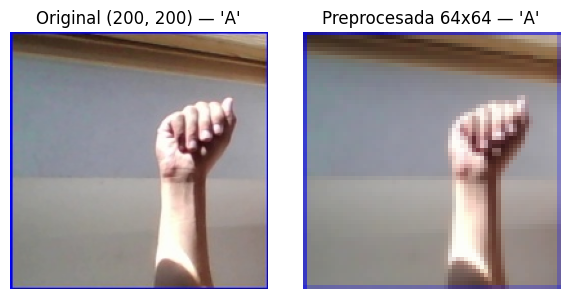

In [ ]:
idx = 0
original = Image.open(sampled_paths[idx]).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(original)
axes[0].set_title(f"Original {original.size} — '{sampled_labels[idx]}'")
axes[0].axis("off")

axes[1].imshow(X[idx])
axes[1].set_title(f"Preprocesada {IMG_SIZE}x{IMG_SIZE} — '{sampled_labels[idx]}'")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 4. Codificación de etiquetas y partición train / validación / prueba

El set de prueba oficial de Kaggle (`asl_alphabet_test/`) trae **solo 1 imagen por clase**, a propósito, para forzar a construir un conjunto de prueba propio — no es útil como conjunto de prueba cuantitativo (no permite estimar una tasa de error confiable). Lo reservamos únicamente para una verificación cualitativa puntual más adelante.

En su lugar, construimos nuestro propio split a partir de la submuestra de 17,400 imágenes:

- **70% entrenamiento / 15% validación / 15% prueba**, con partición **estratificada por clase** para que las 29 clases mantengan la misma proporción en cada conjunto (evita que, por azar, alguna letra quede subrepresentada en validación o prueba).
- Se usa `train_test_split` de scikit-learn dos veces (primero se separa el test, luego se separa la validación del remanente), con la misma semilla fija para reproducibilidad.

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # class_names[i] <-> etiqueta codificada i
class_names = le.classes_

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, stratify=y_encoded, random_state=RANDOM_SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (12180, 64, 64, 3) Val: (2610, 64, 64, 3) Test: (2610, 64, 64, 3)


In [ ]:
# Verificación de que el balance de clases se mantiene en los 3 conjuntos
def class_dist(y_arr, name):
    return pd.Series(y_arr).value_counts(normalize=True).sort_index().rename(name)


dist = pd.concat(
    [class_dist(y_train, "train"), class_dist(y_val, "val"), class_dist(y_test, "test")],
    axis=1,
)
dist.index = class_names
dist.round(4)

,train,val,test
A,0.0345,0.0345,0.0345
B,0.0345,0.0345,0.0345
C,0.0345,0.0345,0.0345
D,0.0345,0.0345,0.0345
E,0.0345,0.0345,0.0345
F,0.0345,0.0345,0.0345
G,0.0345,0.0345,0.0345
H,0.0345,0.0345,0.0345
I,0.0345,0.0345,0.0345
J,0.0345,0.0345,0.0345


## 5. Guardar los datos preprocesados

Guardamos los splits en un único archivo `.npz` comprimido para que los notebooks de modelado (CNNs, red fully-connected, y el tercer algoritmo) carguen directamente los datos ya preprocesados sin repetir este pipeline.

Los píxeles se guardan como **`uint8` (0-255)** en vez de `float32` normalizado — esto reduce el tamaño del archivo en disco 4x sin perder información (la normalización es una operación reversible y barata). Cada notebook de modelado debe dividir entre 255 al cargar los datos. Este archivo se excluye del repositorio vía `.gitignore` por su tamaño; cada integrante lo regenera corriendo este notebook.

In [9]:
OUTPUT_DIR = Path("asl-alphabet/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_path = OUTPUT_DIR / f"asl_{IMG_SIZE}x{IMG_SIZE}_{SAMPLES_PER_CLASS}pc.npz"

np.savez_compressed(
    output_path,
    X_train=(X_train * 255).astype(np.uint8),
    y_train=y_train,
    X_val=(X_val * 255).astype(np.uint8),
    y_val=y_val,
    X_test=(X_test * 255).astype(np.uint8),
    y_test=y_test,
    class_names=class_names,
)

print("Guardado en:", output_path.resolve())
print(f"Tamaño del archivo: {output_path.stat().st_size / 1e6:.1f} MB")

Guardado en: C:\Users\sofia\Documents\DataScience\Lab3-DataScience\asl-alphabet\processed\asl_64x64_600pc.npz
Tamaño del archivo: 184.5 MB


## Resumen del preprocesamiento

| Paso | Decisión | Justificación |
|---|---|---|
| Submuestreo | 600 imágenes/clase (17,400 total) | Reduce el costo de cómputo manteniendo variabilidad; muestreo aleatorio con semilla fija por reproducibilidad |
| Resolución | 200x200 → 64x64 (bilineal) | Balance entre detalle suficiente para distinguir letras similares (M/N/S, U/V/R) y velocidad de entrenamiento |
| Color | Se mantiene RGB (no se convierte a escala de grises) | El color/tono de piel es relevante para la reflexión de accesibilidad del Ejercicio 9; no se descarta en esta etapa |
| Normalización | División entre 255 → rango [0, 1] al cargar | Estándar para estabilizar el entrenamiento de redes neuronales |
| Filtros | Ninguno en esta etapa | Blur, flips, rotaciones, etc. se dejan para el image augmentation del Ejercicio 7, no como preprocesamiento base |
| Partición | 70% train / 15% val / 15% test, estratificada | El test oficial de Kaggle es demasiado pequeño (1 img/clase) para evaluar cuantitativamente; se construye una partición propia y balanceada |
| Almacenamiento | `uint8` en `.npz` comprimido, excluido de git | Evita inflar el repositorio; cada integrante regenera el archivo corriendo este notebook |

